# Supply Chain Performance Analysis

## End-to-End Data Analytics Project

### Tools Used
- Python (Pandas, NumPy, Matplotlib)
- SQL
- Excel
- Tableau

### Project Objective


This project analyzes supply chain and e-commerce shipping data to identify operational inefficiencies and uncover business insights related to revenue generation, inventory management, supplier quality, transportation performance, and customer satisfaction.

The project demonstrates an end-to-end analytics workflow using Excel for initial data validation, Python for exploratory data analysis, SQL for business querying, and Tableau for dashboard development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Dataset Overview

The dataset was imported into Python for exploratory data analysis and business insight generation.

The primary dataset contains supply chain operational data, including product sales, inventory levels, shipping operations, supplier performance, transportation costs, and revenue generation.

### Business Questions

1. Which product categories generate the highest revenue?
2. How do inventory levels vary across products?
3. Which suppliers have the highest defect rates?
4. Do higher transportation costs improve business performance?
5. Which factors contribute to operational efficiency?

The following steps verify the dataset structure before analysis.

In [2]:
import os

print(os.getcwd())

C:\Users\manpr\Downloads


## Data Loading

The dataset is loaded into a Pandas DataFrame to enable data exploration, cleaning, and analysis.

The first few records are reviewed to understand the structure and content of the dataset.

In [3]:
import pandas as pd

df = pd.read_excel("supply_chain_data.xlsx")

df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


## Data Quality Assessment

Before performing exploratory analysis, the dataset structure and quality were evaluated.

The objectives of this assessment are:

- Verify dataset dimensions
- Review data types
- Identify missing values
- Understand variable distributions
- Confirm readiness for analysis

These checks help ensure reliable analytical results and business insights.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

### Observation

The dataset contains 100 records and 24 variables related to supply chain operations, including product information, inventory levels, shipping performance, supplier details, manufacturing metrics, and revenue generation.

All columns contain 100 non-null values, indicating that there are no missing values in the dataset. This reduces the need for extensive data cleaning and allows the analysis to proceed with confidence.

In [5]:
df.shape

(100, 24)

In [6]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

## Descriptive Statistics

Summary statistics were generated to understand the distribution and variability of key numerical variables such as revenue, stock levels, shipping times, shipping costs, and production volumes.

These metrics provide a high-level understanding of operational performance and help identify potential patterns or anomalies.

In [7]:
df.describe ()


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


### Key Insights

The average revenue generated is approximately 5,776, while average stock levels are around 48 units.

Shipping times average approximately 5.75 days and shipping costs average approximately 5.55 units.

The wide range between minimum and maximum values across several variables suggests significant variability in operational performance, making further analysis necessary to identify drivers of business outcomes.

## Revenue Analysis by Product Type

Revenue is a critical business metric because it directly reflects product performance and customer demand.

This analysis evaluates total revenue generated by each product category to identify the highest-performing segments.

In [8]:
revenue_by_product = df.groupby ("Product type") ["Revenue generated"].sum()
print(revenue_by_product)

Product type
cosmetics    161521.265999
haircare     174455.390605
skincare     241628.162133
Name: Revenue generated, dtype: float64


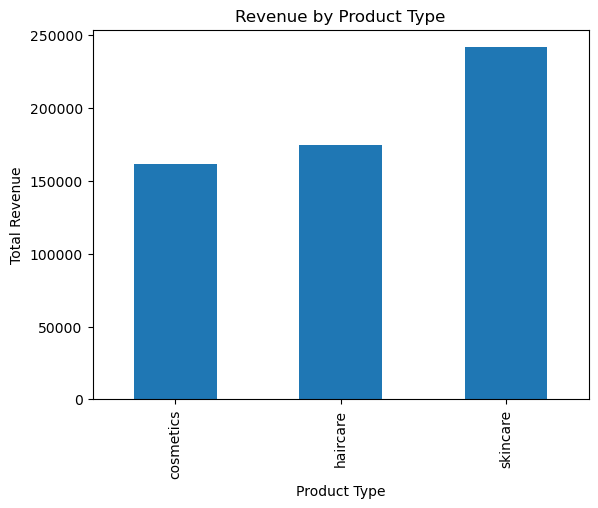

In [9]:
revenue_by_product.plot(kind="bar")
plt.title("Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Total Revenue")
plt.show()

### Revenue Ranking Insight

In [10]:
revenue_by_product.sort_values(ascending=False)


Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

### Key Insights

Skincare products generated the highest total revenue (241,628), significantly outperforming haircare and cosmetics products.

This suggests that skincare products contribute the largest share of business revenue and may represent an opportunity for inventory prioritization, targeted marketing, and demand forecasting.

Understanding revenue concentration helps organizations allocate resources more effectively and maximize profitability.

## Inventory Analysis

Inventory levels play a critical role in supply chain efficiency. Maintaining appropriate stock levels helps organizations avoid stockouts while minimizing excess inventory costs.

This analysis compares average stock levels across product categories.

In [11]:
stock_level_by_product_type = df.groupby ("Product type") ["Stock levels"].mean()
print(stock_level_by_product_type)

Product type
cosmetics    58.653846
haircare     48.352941
skincare     40.200000
Name: Stock levels, dtype: float64


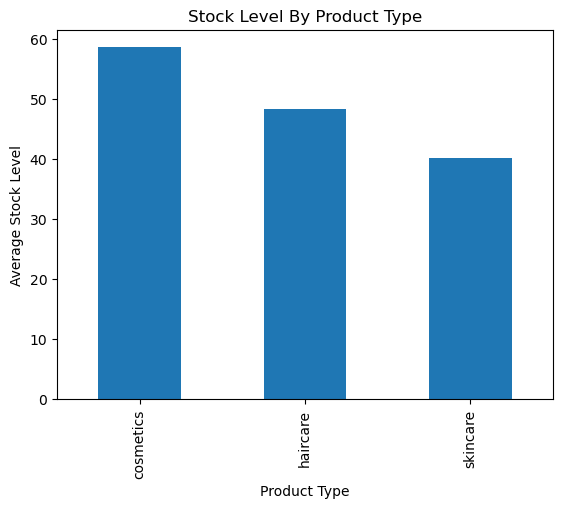

In [12]:
stock_level_by_product_type.plot(kind = "bar")
plt.title ("Stock Level By Product Type")
plt.xlabel ("Product Type")
plt.ylabel ("Average Stock Level")
plt.show()

### Key Insights

Cosmetics products maintain the highest average stock levels, followed by haircare and skincare products.

The differences in inventory levels may reflect variations in customer demand, replenishment strategies, or product turnover rates.

Monitoring inventory levels helps organizations balance product availability with inventory carrying costs.

### Revenue By Product & Location

In [13]:
df.groupby(["Product type","Location"])["Revenue generated"].sum().sort_values(ascending=False).head(10)

Product type  Location 
skincare      Kolkata      77886.265903
              Chennai      58957.419359
haircare      Bangalore    51654.345696
cosmetics     Mumbai       49156.506477
haircare      Mumbai       44423.981964
skincare      Mumbai       44174.538437
cosmetics     Delhi        37429.677331
haircare      Kolkata      35027.713247
skincare      Bangalore    31637.815307
cosmetics     Chennai      31461.947457
Name: Revenue generated, dtype: float64

### Key Insights

Skincare products in Kolkata generated the highest revenue among all product-location combinations.

Additional strong-performing markets included Chennai and Bangalore.

These findings can support regional inventory planning and targeted business expansion strategies.

## Supplier Performance Analysis

Supplier quality directly affects operational efficiency, product reliability, and customer satisfaction.

This analysis evaluates average defect rates across suppliers to identify potential quality risks within the supply chain.

In [14]:
defect_rates_by_supplier_name = df.groupby ("Supplier name") ["Defect rates"].mean()
print(defect_rates_by_supplier_name)

Supplier name
Supplier 1    1.803630
Supplier 2    2.362750
Supplier 3    2.465786
Supplier 4    2.337397
Supplier 5    2.665408
Name: Defect rates, dtype: float64


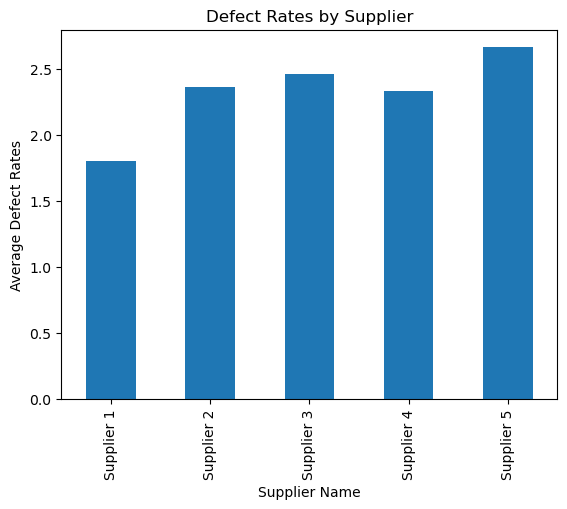

In [15]:
defect_rates_by_supplier_name.plot(kind = "bar")
plt.title ("Defect Rates by Supplier")
plt.xlabel ("Supplier Name")
plt.ylabel ("Average Defect Rates")
plt.show()

### Supplier Ranking Insight

In [16]:
defect_rates_by_supplier_name.sort_values(ascending=False)

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64

### Key Insights

- Supplier 5 recorded the highest average defect rate (2.67%).
- Supplier 1 recorded the lowest average defect rate (1.80%).
- Supplier quality monitoring can help reduce operational defects and improve product quality.

## Transportation Cost Analysis

Transportation costs represent a significant component of supply chain expenses.

This analysis compares average shipping costs across transportation modes to understand cost differences and support logistics decision-making.

In [17]:
Shipping_costs_by_Transportation_modes = df.groupby ("Transportation modes")["Shipping costs"].mean()
print(Shipping_costs_by_Transportation_modes )

Transportation modes
Air     6.017839
Rail    5.469098
Road    5.542115
Sea     4.970294
Name: Shipping costs, dtype: float64


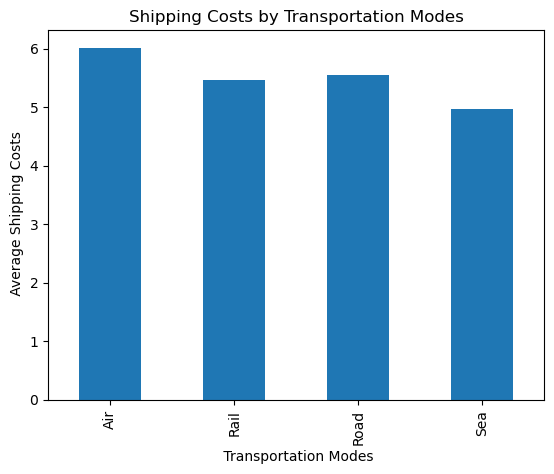

In [18]:
Shipping_costs_by_Transportation_modes.plot(kind = "bar")
plt.title ("Shipping Costs by Transportation Modes")
plt.xlabel (" Transportation Modes")
plt.ylabel (" Average Shipping Costs")
plt.show()

### Key Insights

Air transportation recorded the highest average shipping cost,
while Sea transportation showed the lowest average shipping cost.

Organizations can reduce logistics expenses by optimizing shipment
allocation across transportation modes while balancing delivery speed.

## Business Summary Table

A summary table was created to consolidate key performance indicators including revenue generation, inventory levels, and supplier defect rates across product categories.

This provides decision-makers with a concise view of operational performance.

In [19]:
summary_table = df.groupby("Product type").agg({
    "Revenue generated":"sum",
    "Stock levels":"mean",
    "Defect rates":"mean"
})

summary_table.columns = [
    "Total Revenue",
    "Average Stock",
    "Average Defect Rate"
]

summary_table

,Total Revenue,Average Stock,Average Defect Rate
Product type,,,
cosmetics,161521.265999,58.653846,1.919287
haircare,174455.390605,48.352941,2.483150
skincare,241628.162133,40.200000,2.334681


### Key Insights

- Skincare products generated the highest total revenue despite having the lowest average inventory levels.
- Cosmetics maintained the highest average inventory levels and the lowest average defect rate.
- Haircare products recorded the highest average defect rate among all product categories.
- This consolidated view helps identify trade-offs between revenue generation, inventory management, and product quality performance.

# Supply Chain Dataset Summary

## Key Findings

- Skincare products generated the highest total revenue among all product categories, indicating strong demand and revenue contribution.
- Cosmetics maintained the highest average inventory levels, while skincare products had lower stock levels despite generating the highest revenue.
- Supplier defect rates varied across suppliers, with Supplier 5 recording the highest average defect rate and Supplier 1 showing the lowest defect rate.
- Air transportation had the highest average shipping cost, while sea transportation had the lowest average shipping cost.
- Product category performance, supplier quality, inventory levels, and transportation costs all played important roles in overall supply chain performance.

## Business Recommendations

1. Prioritize inventory planning for skincare products to support strong demand and reduce the risk of stock shortages.
2. Monitor suppliers with higher defect rates and create quality improvement plans.
3. Use Supplier 1 as a benchmark for stronger supplier quality performance.
4. Optimize transportation mode selection by balancing shipping costs with delivery requirements.
5. Continue tracking revenue, inventory, defect rates, and transportation costs through dashboards and regular reporting.

## Conclusion

The supply chain analysis shows that skincare products are the strongest revenue driver, while inventory levels, supplier quality, and transportation costs influence overall operational performance.

By using data-driven insights, organizations can improve inventory planning, reduce supplier-related risks, manage logistics costs, and support better business decision-making.

## E-Commerce Shipping Dataset Analysis

A second dataset was included to analyze customer delivery performance and shipment operations.

This dataset contains information related to shipment methods, customer ratings, customer service interactions, product importance, and delivery outcomes.

The analysis aims to identify factors that influence customer satisfaction and shipment performance.

In [20]:
import pandas as pd

df2 = pd.read_csv("Train.csv")

df2.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## Dataset Structure

The e-commerce shipping dataset contains customer, shipment, and delivery-related variables. Key attributes include shipment mode, customer ratings, product importance, prior purchases, and delivery status.

These variables provide the foundation for analyzing factors that influence customer satisfaction and shipment performance.

In [21]:
df2.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

## Customer Satisfaction Analysis

Customer satisfaction is an important indicator of delivery performance and service quality.

This analysis compares average customer ratings between shipments delivered on time and shipments that experienced delays.

In [22]:
Customer_rating_by_delivery = df2.groupby ("Reached.on.Time_Y.N")["Customer_rating"].mean()
print(Customer_rating_by_delivery)

Reached.on.Time_Y.N
0    2.967989
1    3.005790
Name: Customer_rating, dtype: float64


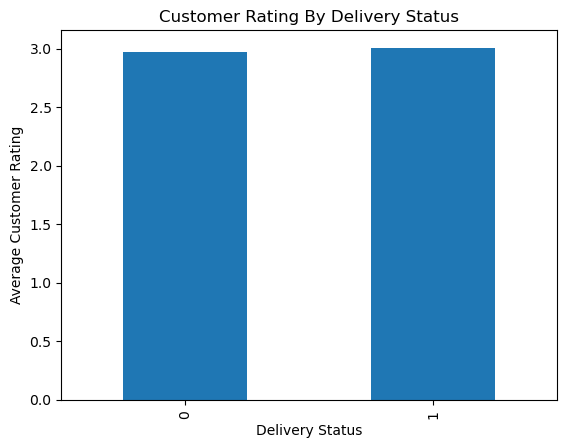

In [23]:
Customer_rating_by_delivery.plot (kind = "bar")
plt.title ("Customer Rating By Delivery Status")
plt.xlabel ("Delivery Status")
plt.ylabel ("Average Customer Rating")
plt.show()

### Key Insights

Customer ratings were very similar for both delivery outcomes, with on-time deliveries receiving a slightly higher average rating.

The small difference suggests that delivery timing alone may not be the primary driver of customer satisfaction. Other factors such as product quality, pricing, and customer service interactions may have a greater influence on customer perceptions.

Organizations should monitor additional customer experience metrics rather than focusing exclusively on delivery speed.

## Shipment Mode Analysis

Different transportation modes can affect delivery speed, cost, and customer experience.

This analysis evaluates whether customer satisfaction varies across shipment methods.

In [24]:
Customer_rating_by_Mode_of_Shipment = df2.groupby ("Mode_of_Shipment")["Customer_rating"].mean()
print(Customer_rating_by_Mode_of_Shipment)

Mode_of_Shipment
Flight    2.982555
Road      2.995455
Ship      2.991289
Name: Customer_rating, dtype: float64


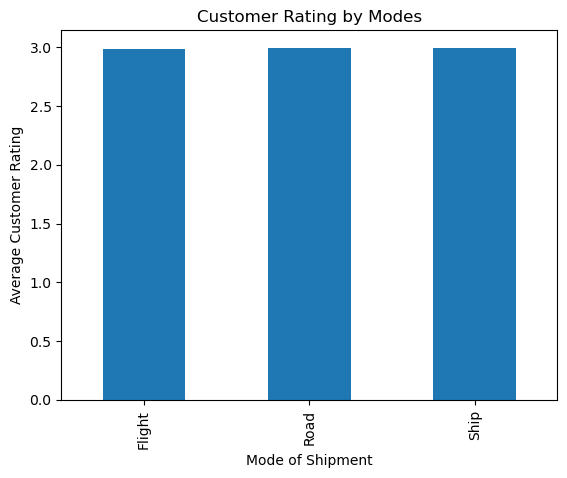

In [25]:
Customer_rating_by_Mode_of_Shipment.plot (kind ="bar")
plt.title ("Customer Rating by Modes")
plt.xlabel ("Mode of Shipment")
plt.ylabel ("Average Customer Rating")
plt.show()

### Key Insights

Customer ratings were nearly identical across Flight, Road, and Ship transportation modes.

The results suggest that customers do not strongly differentiate their satisfaction based on shipment mode alone.

This indicates that organizations may have flexibility in selecting transportation methods based on cost and operational efficiency without significantly affecting customer satisfaction.

## Customer Demographic Analysis

Understanding customer satisfaction across demographic groups helps organizations evaluate whether service quality is being delivered consistently.

This analysis compares average customer ratings between male and female customers.

In [26]:
Customer_rating_by_Gender = df2.groupby ("Gender")["Customer_rating"].mean()
print(Customer_rating_by_Gender)

Gender
F    2.986655
M    2.994499
Name: Customer_rating, dtype: float64


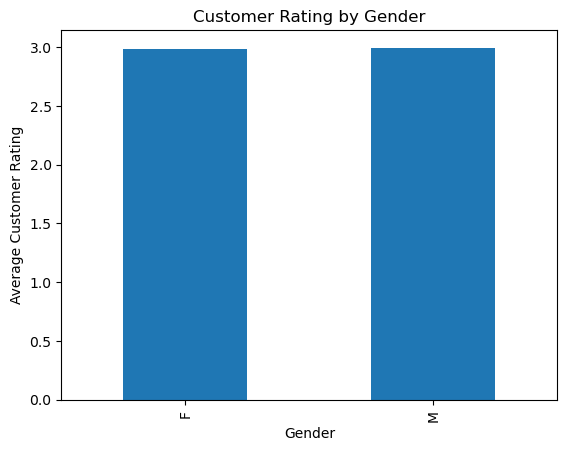

In [27]:
Customer_rating_by_Gender.plot(kind = "bar")
plt.title ("Customer Rating by Gender")
plt.xlabel ("Gender")
plt.ylabel ("Average Customer Rating")
plt.show()

### Key Insights

Customer ratings were almost identical between male and female customers.

This suggests that customer satisfaction levels are consistent across gender groups and that the organization is providing a relatively uniform customer experience.

No significant demographic differences were observed in customer rating behavior.

# E-Commerce Shipping Dataset Summary

### Key Findings

- Customer ratings showed minimal variation between on-time and delayed deliveries.
- Shipment mode had little impact on customer satisfaction.
- Customer ratings were consistent across demographic groups.
- Customer satisfaction appears to be influenced by factors beyond transportation method and delivery timing.

### Business Recommendations

1. Continue monitoring delivery performance while investigating additional customer experience drivers.
2. Focus on product quality and customer service improvements to increase customer satisfaction.
3. Optimize transportation mode selection based on cost and operational efficiency rather than customer rating differences.
4. Develop additional customer feedback metrics to better understand satisfaction drivers.

### Conclusion

The analysis suggests that customer satisfaction is relatively stable across different delivery conditions and customer groups. Future analysis should focus on identifying additional factors that contribute to customer experience and long-term customer loyalty.